In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import datetime as dt

In [2]:
# get daily data

df = pl.scan_ipc('crsp_daily.ftr')

In [3]:
# add log return col and keep only what we need (keep shr for market equity)

df = (
    df
    .with_columns(
        pl.col('caldt').dt.date()
    )
    .with_columns(
        pl.col('ret').log1p().alias('logret')
    )
    .drop(['siccd','vol','excd'])
)

In [ ]:
# filter to dates from paper

df = df.filter((pl.col('caldt') >= dt.date(1965,1,1)) & (pl.col('caldt') <= dt.date(2002,12,31)))

In [5]:
# create ret_1m monthly returns for replication

df = (
    df
    .with_columns(
        pl.col('caldt').dt.truncate('1mo').alias('month')
    )
    .with_columns(
        pl.col('logret').sum().over(['permno','month']).exp().sub(1).alias('ret_1m')
    )
    .sort(['permno','month'])
)

In [6]:
# collapse daily to one row per firm/month combo (hence mdf = monthly dataframe)
# build market equity, lag price and ME for next-month portfolio formation

mdf = (
    df
    .group_by(['permno','month'])
    .agg(
        pl.col('ret_1m').first(),
        pl.col('prc').last().alias('prc'),
        pl.col('shr').last().alias('shr'),
        pl.col('shrcd').last().alias('shrcd'),
    )
    .sort(['permno','month'])
    .with_columns(
        pl.when(pl.col('prc').abs() * pl.col('shr') > 1e-6)
          .then(pl.col('prc').abs() * pl.col('shr') / 1000.0)
          .otherwise(None)
          .alias('me')
    )
    .with_columns(
        pl.col('prc','me').shift().over('permno').name.suffix('lag')
    )
    .filter(
        pl.col('shrcd').is_between(10, 11) &
        pl.col('melag').is_not_null() &
        (pl.col('prclag').abs() > 5.0)
    )
)

In [8]:
# take average of same calendar month returns at appropriate lags

lags = list(range(12, 241, 12))

lag_exprs = [pl.col('ret_1m').shift(k).over('permno') for k in lags]

mdf = (
    mdf
    .sort(['permno','month'])
    .with_columns(
        pl.sum_horizontal([e.fill_null(0.0) for e in lag_exprs]).alias('seasonal_sum'),
        pl.sum_horizontal([e.is_not_null().cast(pl.Int32) for e in lag_exprs]).alias('seasonal_count'),
    )
    .with_columns(
        pl.when(pl.col('seasonal_count') > 0)
          .then(pl.col('seasonal_sum') / pl.col('seasonal_count'))
          .otherwise(None)
          .alias('seasonal_signal')
    )
    .drop(['seasonal_sum','seasonal_count'])
    .filter(
        pl.col('seasonal_signal').is_not_null() &
        pl.col('ret_1m').is_not_null()
    )
)

In [12]:
# quintile sort each month on the seasonality signal, compute equal weight and vw returns

port = (
    mdf
    .with_columns(
        pl.col('seasonal_signal')
          .qcut(5, labels=[f'p{i}' for i in range(5)])
          .over('month')
          .alias('port'),
        (pl.col('melag') * pl.col('ret_1m')).alias('meret'),
    )
    .group_by(['month','port'])
    .agg(
        (pl.col('ret_1m') * 100).mean().alias('ewret'),
        (pl.col('meret')  * 100).sum().alias('vwret_num'),
        pl.col('melag').sum().alias('wtotal'),
        pl.len().alias('n'),
    )
    .with_columns(
        (pl.col('vwret_num') / pl.col('wtotal')).alias('vwret')
    )
    .sort(['month','port'])
).collect(engine='streaming')

# pivot to wide for visualization purposes

ew = port.pivot(index='month', on='port', values='ewret').sort('month')
vw = port.pivot(index='month', on='port', values='vwret').sort('month')

ew.head()

month,p0,p1,p2,p3,p4
date,f64,f64,f64,f64,f64
1967-02-01,2.295912,1.837933,2.071381,3.172578,4.038658
1967-03-01,5.733392,5.678597,5.676903,4.756757,5.600942
1967-04-01,3.854334,2.883916,4.381825,4.686386,4.39334
1967-05-01,-1.726288,-1.716894,-1.593215,-1.712935,-0.807097
1967-06-01,7.892683,5.888669,4.977209,5.387219,8.308021


In [13]:
# get summary stats and spread portfolio (probably could've just used Regtables from fin585 lib in hindsight...)

def summarize(wide, label):
    wide = wide.with_columns((pl.col('p4') - pl.col('p0')).alias('LS'))
    pdf = wide.select(['month','p0','p1','p2','p3','p4','LS']).to_pandas().set_index('month')
    n = len(pdf)
    stats = pdf.agg(['mean','std']).T
    stats['t'] = stats['mean'] / (stats['std'] / np.sqrt(n))

    # use claude to make it look nice
    print(f'- {label}  |  {pdf.index.min()} to {pdf.index.max()}  |  N={n} months -')
    print(stats.round(3))
    print()
    return wide

ew = summarize(ew, 'Equal-weighted (monthly %)')
vw = summarize(vw, 'Value-weighted (monthly %)')

- Equal-weighted (monthly %)  |  1967-02-01 00:00:00 to 2002-12-01 00:00:00  |  N=431 months -
     mean    std      t
p0  0.892  6.030  3.071
p1  1.025  4.856  4.382
p2  1.207  4.705  5.327
p3  1.341  5.013  5.552
p4  1.361  6.273  4.505
LS  0.469  1.776  5.482

- Value-weighted (monthly %)  |  1967-02-01 00:00:00 to 2002-12-01 00:00:00  |  N=431 months -
     mean    std      t
p0  0.565  5.907  1.984
p1  0.660  4.671  2.933
p2  0.933  4.435  4.366
p3  1.132  4.783  4.913
p4  1.314  6.114  4.460
LS  0.749  3.236  4.806



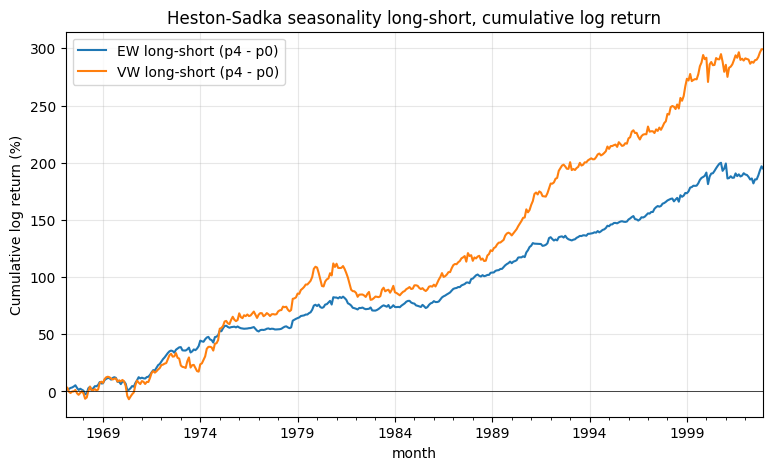

In [14]:
# cumulative log return of spread portfolio

fig, ax = plt.subplots(figsize=(9, 5))
for wide, name in [(ew, 'EW'), (vw, 'VW')]:
    s = wide.select(['month','LS']).to_pandas().set_index('month')['LS'] / 100.0
    cum_log_pct = 100.0 * np.log1p(s).cumsum()
    cum_log_pct.plot(ax=ax, label=f'{name} long-short (p4 - p0)')
ax.set_title('Heston-Sadka seasonality long-short, cumulative log return')
ax.set_ylabel('Cumulative log return (%)')
ax.axhline(0.0, color='k', lw=0.5)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Table 1 replication

For each lag $k$, regress month-$t$ returns cross-sectionally on month $(t-k)$ returns,
then average the slopes across months. Heston-Sadka show coefficients spike at multiples
of 12 and the lag-1 short-term reversal shows up as a negative slope.

shape: (24, 4)
┌─────┬────────────┬───────────┬───────────┐
│ lag ┆ mean_slope ┆ t_stat    ┆ n_periods │
│ --- ┆ ---        ┆ ---       ┆ ---       │
│ i64 ┆ f64        ┆ f64       ┆ i64       │
╞═════╪════════════╪═══════════╪═══════════╡
│ 1   ┆ -0.019713  ┆ -4.333503 ┆ 454       │
│ 2   ┆ 0.013506   ┆ 3.286271  ┆ 453       │
│ 3   ┆ 0.019837   ┆ 5.019683  ┆ 452       │
│ 4   ┆ 0.011237   ┆ 2.979874  ┆ 451       │
│ 5   ┆ 0.012204   ┆ 3.09343   ┆ 450       │
│ …   ┆ …          ┆ …         ┆ …         │
│ 20  ┆ -0.005925  ┆ -2.291842 ┆ 435       │
│ 21  ┆ -0.003653  ┆ -1.371444 ┆ 434       │
│ 22  ┆ -0.003692  ┆ -1.43467  ┆ 433       │
│ 23  ┆ -0.007431  ┆ -2.780445 ┆ 432       │
│ 24  ┆ 0.006063   ┆ 2.253987  ┆ 431       │
└─────┴────────────┴───────────┴───────────┘


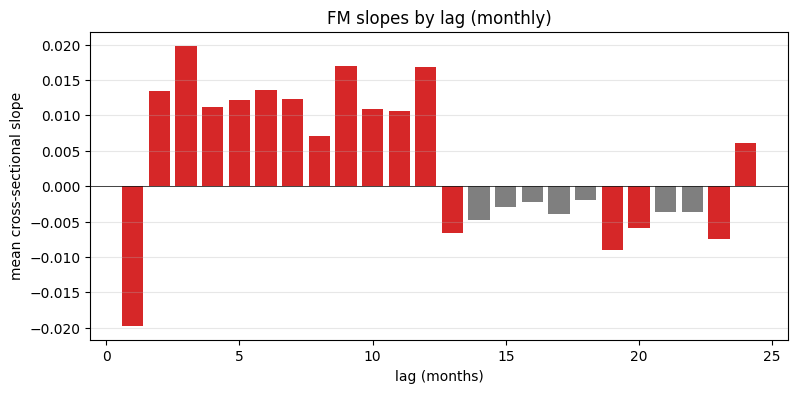

In [ ]:
# Fama-MacBeth regression(s): cross-sectional slope of ret_t on ret_{t-k}

def fama(panel, ret_col, time_col, lags, group='permno'):
    base = panel.select([group, time_col, ret_col]).sort([group, time_col])
    rows = []
    for k in lags:
        d = (
            base
            .with_columns(pl.col(ret_col).shift(k).over(group).alias('x'))
            .drop_nulls(['x', ret_col])
        )
        cs = (
            d.group_by(time_col)
             .agg(
                 pl.cov(pl.col(ret_col), pl.col('x')).alias('cov'),
                 pl.col('x').var().alias('var'),
                 pl.len().alias('n'),
             )
             .filter((pl.col('var') > 0) & (pl.col('n') > 10))
        )
        b = (cs['cov'] / cs['var']).drop_nulls().to_numpy()
        if len(b) > 1:
            rows.append((k, float(b.mean()),
                         float(b.mean() / (b.std(ddof=1) / np.sqrt(len(b)))), len(b)))
    return pl.DataFrame(rows, schema=['lag','mean_slope','t_stat','n_periods'], orient='row')

def plot_fama(table, xlabel, title):
    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ['tab:red' if abs(t) > 1.96 else 'tab:gray' for t in table['t_stat']]
    ax.bar(table['lag'].to_list(), table['mean_slope'].to_list(), color=colors)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel(xlabel); ax.set_ylabel('mean cross-sectional slope')
    ax.set_title(title)
    ax.grid(True, axis='y', alpha=0.3)
    plt.show()

# clean monthly df for fama macbeth
mbase = (
    df.group_by(['permno','month'])
      .agg(
          pl.col('ret_1m').first(),
          pl.col('prc').last().alias('prc'),
          pl.col('shrcd').last().alias('shrcd'),
      )
      .sort(['permno','month'])
      .with_columns(pl.col('prc').shift().over('permno').alias('prclag'))
      .filter(
          pl.col('shrcd').is_between(10, 11) &
          (pl.col('prclag').abs() > 5.0) &
          pl.col('ret_1m').is_not_null()
      )
).collect(engine='streaming')

table1 = fama(mbase, 'ret_1m', 'month', list(range(1, 25))) # I don't remember if these are the same lags in Table 1 from the paper, so please change if necessary
print(table1)
plot_fama(table1, 'lag (months)', 'FM slopes by lag (monthly)')

## Extension (inter-month rather than calendar month)

Same monthly methodology as the replication, but periods run from the 16th of one
calendar month to the 15th of the next, so there are still 12 periods per year, and still annual lags
$12, 24, \dots, 240$ for the seasonal signal. Tests whether the seasonal effect is
specific to the calendar-month boundary or robust to a half-month shift (assumption is generally surrounding big funds and their allocation parameters)

Basically just copied and pasted everything after shifting dates. Here we found it easier to shift dates rather than shifting all the other columns as we normally would.

In [17]:
# build "shifted" dataframe sdf where each period runs from the 16th of one calendar month to the 15th of the next

sdf = (
    df
    .with_columns(
        pl.col('caldt').dt.offset_by('-15d').dt.truncate('1mo').alias('shmonth') # offset_by uses calendar days, not trading days
    )
    .with_columns(
        pl.col('logret').sum().over(['permno','shmonth']).exp().sub(1).alias('ret_sm')
    )
    .group_by(['permno','shmonth'])
    .agg(
        pl.col('ret_sm').first(),
        pl.col('prc').last().alias('prc'),
        pl.col('shr').last().alias('shr'),
        pl.col('shrcd').last().alias('shrcd'),
    )
    .sort(['permno','shmonth'])
    .with_columns(
        pl.when(pl.col('prc').abs() * pl.col('shr') > 1e-6)
          .then(pl.col('prc').abs() * pl.col('shr') / 1000.0)
          .otherwise(None)
          .alias('me')
    )
    .with_columns(
        pl.col('prc','me').shift().over('permno').name.suffix('lag')
    )
    .filter(
        pl.col('shrcd').is_between(10, 11) &
        pl.col('melag').is_not_null() &
        (pl.col('prclag').abs() > 5.0)
    )
)

- Shifted-month EW (monthly %)  |  1966-01-01 00:00:00 to 2002-12-01 00:00:00  |  N=444 months -
     mean    std      t
p0  0.884  6.302  2.957
p1  1.007  5.010  4.236
p2  1.149  4.896  4.947
p3  1.333  5.231  5.369
p4  1.204  6.694  3.789
LS  0.319  1.656  4.062

- Shifted-month VW (monthly %)  |  1966-01-01 00:00:00 to 2002-12-01 00:00:00  |  N=444 months -
     mean    std      t
p0  0.498  5.888  1.781
p1  0.652  4.715  2.914
p2  0.832  4.419  3.967
p3  1.232  4.718  5.502
p4  1.197  6.424  3.926
LS  0.699  3.035  4.853



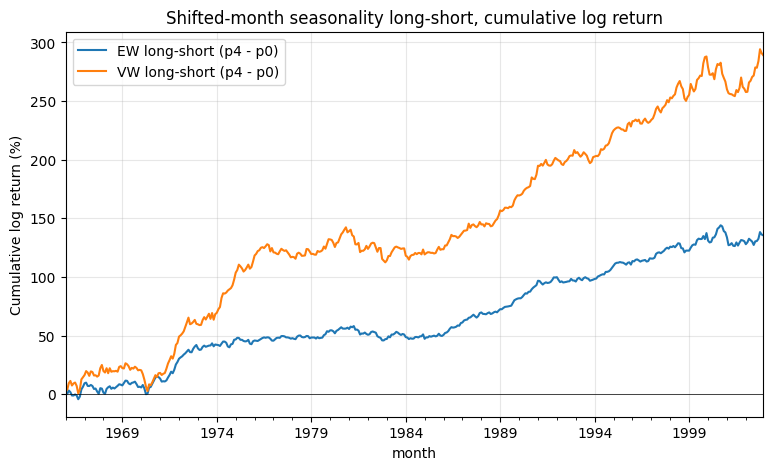

In [18]:
# same Heston-Sadka signal as monthly, just on our shifted periods

shifted_lag_exprs = [pl.col('ret_sm').shift(k).over('permno') for k in lags]

sdf = (
    sdf
    .sort(['permno','shmonth'])
    .with_columns(
        pl.sum_horizontal([e.fill_null(0.0) for e in shifted_lag_exprs]).alias('seasonal_sum'),
        pl.sum_horizontal([e.is_not_null().cast(pl.Int32) for e in shifted_lag_exprs]).alias('seasonal_count'),
    )
    .with_columns(
        pl.when(pl.col('seasonal_count') > 0)
          .then(pl.col('seasonal_sum') / pl.col('seasonal_count'))
          .otherwise(None)
          .alias('seasonal_signal')
    )
    .drop(['seasonal_sum','seasonal_count'])
    .filter(
        pl.col('seasonal_signal').is_not_null() &
        pl.col('ret_sm').is_not_null()
    )
)

shifted_port = (
    sdf
    .with_columns(
        pl.col('seasonal_signal').qcut(5, labels=[f'p{i}' for i in range(5)]).over('shmonth').alias('port'),
        (pl.col('melag') * pl.col('ret_sm')).alias('meret'),
    )
    .group_by(['shmonth','port'])
    .agg(
        (pl.col('ret_sm') * 100).mean().alias('ewret'),
        (pl.col('meret')  * 100).sum().alias('vwret_num'),
        pl.col('melag').sum().alias('wtotal'),
    )
    .with_columns((pl.col('vwret_num') / pl.col('wtotal')).alias('vwret'))
    .sort(['shmonth','port'])
).collect(engine='streaming')

sew = shifted_port.pivot(index='shmonth', on='port', values='ewret').sort('shmonth').rename({'shmonth':'month'})
svw = shifted_port.pivot(index='shmonth', on='port', values='vwret').sort('shmonth').rename({'shmonth':'month'})

sew = summarize(sew, 'Shifted-month EW (monthly %)')
svw = summarize(svw, 'Shifted-month VW (monthly %)')

fig, ax = plt.subplots(figsize=(9, 5))
for wide, name in [(sew, 'EW'), (svw, 'VW')]:
    s = wide.select(['month','LS']).to_pandas().set_index('month')['LS'] / 100.0
    (100.0 * np.log1p(s).cumsum()).plot(ax=ax, label=f'{name} long-short (p4 - p0)')
ax.set_title('Shifted-month seasonality long-short, cumulative log return')
ax.set_ylabel('Cumulative log return (%)')
ax.axhline(0.0, color='k', lw=0.5)
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

shape: (24, 4)
┌─────┬────────────┬───────────┬───────────┐
│ lag ┆ mean_slope ┆ t_stat    ┆ n_periods │
│ --- ┆ ---        ┆ ---       ┆ ---       │
│ i64 ┆ f64        ┆ f64       ┆ i64       │
╞═════╪════════════╪═══════════╪═══════════╡
│ 1   ┆ -0.019023  ┆ -4.37887  ┆ 455       │
│ 2   ┆ 0.014897   ┆ 3.60106   ┆ 454       │
│ 3   ┆ 0.016981   ┆ 4.551364  ┆ 453       │
│ 4   ┆ 0.010128   ┆ 2.598182  ┆ 452       │
│ 5   ┆ 0.012115   ┆ 3.004806  ┆ 451       │
│ …   ┆ …          ┆ …         ┆ …         │
│ 20  ┆ -0.008706  ┆ -3.142004 ┆ 436       │
│ 21  ┆ -0.004176  ┆ -1.648161 ┆ 435       │
│ 22  ┆ -0.004789  ┆ -1.833151 ┆ 434       │
│ 23  ┆ -0.006455  ┆ -2.450141 ┆ 433       │
│ 24  ┆ 0.003969   ┆ 1.620637  ┆ 432       │
└─────┴────────────┴───────────┴───────────┘


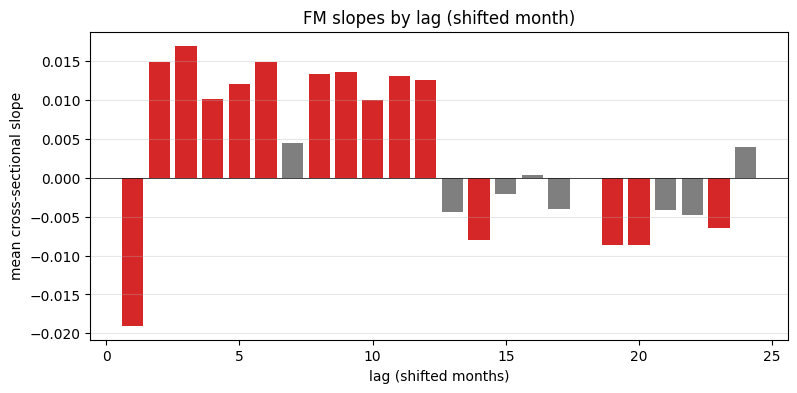

In [19]:
# Table 1-style Fama-Macbeth regression(s) on sdf

sbase = (
    df
    .with_columns(
        pl.col('caldt').dt.offset_by('-15d').dt.truncate('1mo').alias('shmonth')
    )
    .with_columns(
        pl.col('logret').sum().over(['permno','shmonth']).exp().sub(1).alias('ret_sm')
    )
    .group_by(['permno','shmonth'])
    .agg(
        pl.col('ret_sm').first(),
        pl.col('prc').last().alias('prc'),
        pl.col('shrcd').last().alias('shrcd'),
    )
    .sort(['permno','shmonth'])
    .with_columns(pl.col('prc').shift().over('permno').alias('prclag'))
    .filter(
        pl.col('shrcd').is_between(10, 11) &
        (pl.col('prclag').abs() > 5.0) &
        pl.col('ret_sm').is_not_null()
    )
).collect(engine='streaming')

table1_shifted = fama(sbase, 'ret_sm', 'shmonth', list(range(1, 25)))
print(table1_shifted)
plot_fama(table1_shifted, 'lag (shifted months)', 'FM slopes by lag (shifted month)')